In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score

In [3]:
(x_train, y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
print("Training Images:",x_train.shape)
print("Training Labels:",y_train.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)


In [5]:
print("Testing Images:",x_test.shape)
print("Testing Labels:",y_test.shape)

Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


## Display Sample Images

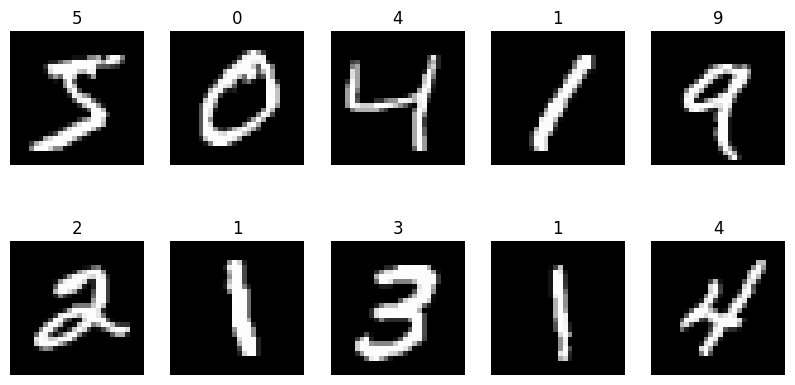

In [11]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## Check Distribution

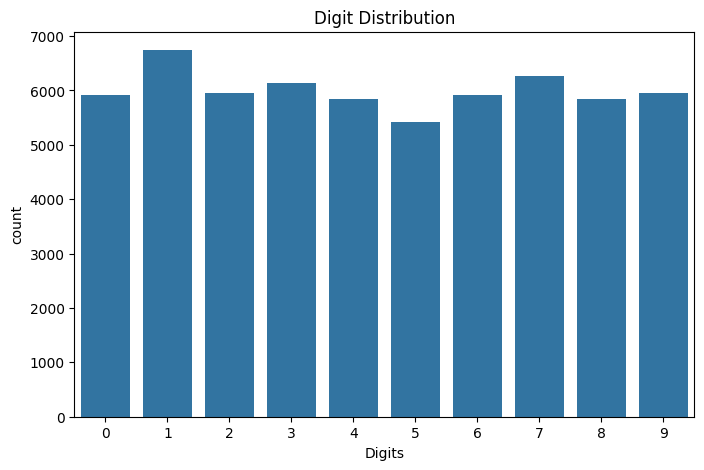

In [13]:
unique, count=np.unique(y_train, return_counts=True)
plt.figure(figsize=(8,5))
sns.barplot(x=unique, y=count)
plt.title("Digit Distribution")
plt.xlabel("Digits")
plt.ylabel("count")
plt.show()

### Data Process

In [15]:
x_train_flat=x_train.reshape(60000,784)
x_test_flat=x_test.reshape(10000,784)
print(x_train_flat.shape)

(60000, 784)


In [16]:
x_train_flat=x_train_flat/255.0
x_test_flat=x_test_flat/255.0

### Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=100)
lr.fit(x_train_flat, y_train)
y_pred_lr=lr.predict(x_test_flat)
acc_lr=accuracy_score(y_test,y_pred_lr)
print("LogisticRegression Accuracy:",acc_lr)

LogisticRegression Accuracy: 0.9257


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat,y_train)
y_pred_knn=knn.predict(x_test_flat)
acc_knn=accuracy_score(y_test,y_pred_knn)
print("KNN Accuracy:",acc_knn)

KNN Accuracy: 0.9705


### Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train_flat,y_train)
y_pred_rf=rf.predict(x_test_flat)
acc_rf=accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy :",acc_rf)

Random Forest Accuracy : 0.9704


## SVM

In [28]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train_flat, y_train)
y_pred_svm=svm.predict(x_test_flat)
acc_svm=accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy :", acc_svm)

SVM Accuracy : 0.9792


## CNN 

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [32]:
x_train_cnn=x_train.reshape(-1,28,28,1)/255.0
x_test_cnn=x_test.reshape(-1,28,28,1)/255.0

### Build Cnn

In [34]:
cnn=Sequential()
cnn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
        
    )
)
cnn.add(
    MaxPooling2D(2,2)
)
cnn.add(Flatten())
cnn.add(
    Dense(
        128,
        activation='relu'
    )
)
cnn.add(
    Dense(
        10,
        activation='softmax'
    )
)

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
cnn.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Train CNN

In [36]:
history=cnn.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_data=(x_test_cnn,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9560 - loss: 0.1486 - val_accuracy: 0.9795 - val_loss: 0.0658
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9839 - loss: 0.0511 - val_accuracy: 0.9837 - val_loss: 0.0476
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9900 - loss: 0.0313 - val_accuracy: 0.9879 - val_loss: 0.0367
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9853 - val_loss: 0.0475
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9956 - loss: 0.0136 - val_accuracy: 0.9859 - val_loss: 0.0440


In [37]:
loss, acc_cnn =cnn.evaluate(
    x_test_cnn,
    y_test
)
print('cnn Accuracy :', acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9859 - loss: 0.0440
cnn Accuracy : 0.9858999848365784


### Models Comparition

In [38]:
results=pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'SVM',
        'CNN'
    ],
    'Accuracy':[
        acc_lr,
        acc_knn,
        acc_rf,
        acc_svm,
        acc_cnn
    ]
}
    )
print(results)

                 Model  Accuracy
0  Logistic Regression    0.9257
1                  KNN    0.9705
2        Random Forest    0.9704
3                  SVM    0.9792
4                  CNN    0.9859


## Graph

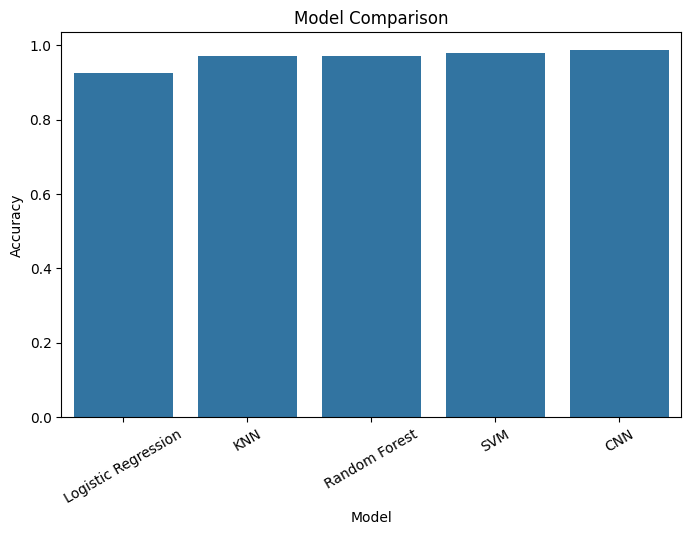

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)
plt.xticks(rotation=30)
plt.title('Model Comparison')
plt.show()

## Best Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


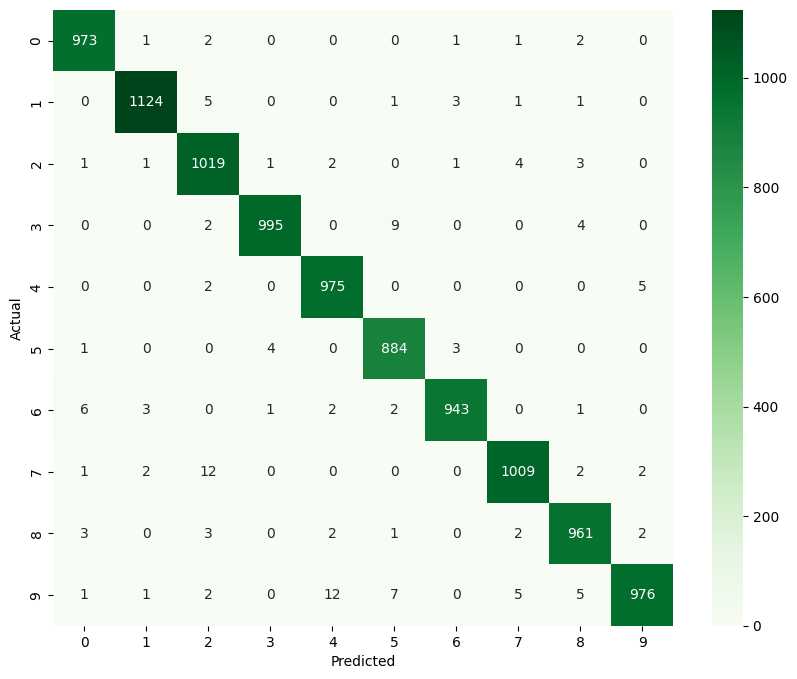

In [51]:
from sklearn.metrics import confusion_matrix
y_pred=cnn.predict(x_test_cnn)
y_pred=np.argmax(y_pred, axis=1)
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Conclution Report

1. Performed EDA on MNIST Dataset.
2. Applied Data Preprocesing and Normalization.
3. Trained Logistic Regression, KNN, Random Forest, SVM, and CNN.
4. Compared model accuracy
5. Cnn is Recommended For Production Deployement

## Challenges Faced

1. High-demensional image Data.
   I yoused for after
   Applied Normalization.
2. Training Time was High.
    so i trained for optimized parameters.
3. image classification complexity
   so i yoused for convalutional Nural network for future Extraction    